Authors: Stefan Kiebel, Alex Lepauvre
# Policy compression

From what we've found so far, it seems that humans probably do not learn tasks by compressing the state representation. A natural alternative is that the simplification happens at the level of the policy rather than the state representation. Instead of reducing the number of states that need to be represented, people may rely on a relatively simple default policy that is only adjusted when the expected value of doing so becomes sufficiently large.
This idea appears in the policy compression framework, which provides a formal way to describe how agents balance reward maximization with the simplicity of their behavioral policy. 


The idea is the following. In classical reinforcement learning framework, action selection is modelled as a softmax rule on the state action value function:

$$
\pi(a|s) \propto e^{(\beta Q(s, a))}
$$

Where $\beta$ is an inverse temperature parameter. But in the policy compression framework, the agent faces constraints regarding how complex the policy can be (due to limits in working memory, computation resources and whatnot), which can be measured as the mutual information between the states and the actions:

$$
I(S, A) = \sum_s P(s) \sum_a \pi (a|s) log (\frac{\pi(a, s)}{P(a)})
$$


Which measures how strongly the choice of action depends on states. When maximizing reward under a complexity constraint, the optimal policy becomes:

$$
\pi(a|s) \propto e^{\beta Q(s,a) + log(P(a))}
$$

Where $P(a)$ is the marginal action probability across states (i.e. the frequency of each action). So in other words, participants are making their decision based on a combination between the reward maximizing action from the Q function (derived from dynamic programming or otherwise) and a prior over actions. The $\beta$ weight that trade off, such that the relative importance of the prior can be weighted up or down. The idea being that if you are making decision under pressure, the prior should be weighted higher to make a decision quickly. 

It could be that participants actually perform abstraction by defining priors derived from previous experiences in solving similar tasks to perform the task. Importantly, depending on the precision of the prior, it will weight more or less in the decision relative to the state action value function. It could be that participants therefore have strong priors about what to do for the most extreme offers and less so for the intermediate ones. 

We will test this idea quite simply by computing a prior over action by using the marginal probability of performing each action across all states that participants encounter, to see whether that gives us a better fit than just taking the decision values.+



## Policy compression model fitting
So far, we have modelled participant's responses data using a logist regression function of Q. This is equivalent to modelling participants responses as a softmax function on the Q function:

$$
P(a=0) = \frac{e^{\beta Q(a=0|s)}}{\sum_{i=0}^k \beta e^{Q(a=i|s)}}
$$

Where k is the actions set. Since we have only two possible actions, the softmax can be simplified to a logit function on the difference in Q values:

$$
\begin{aligned}
P(a=0) &= \frac{e^{\beta  Q(a=0|s)}}{e^{\beta  Q(a=0|s)} + e^{\beta  Q(a=1|s)}} \\

P(a=0) &= \frac{e^{\beta Q(a=0|s)}}{e^{\beta  Q(a=0|s)} + e^{\beta Q(a=1|s)}} \times \frac{e^{-\beta Q(a=0|s)}}{e^{-\beta Q(a=0|s)}} \\

P(a=0) &= \frac{1}{e^{\beta  Q(a=0|s)-\beta Q(a=0|s)} + e^{\beta Q(a=1|s)-\beta Q(a=0|s)}} \\

P(a=0) &= \frac{1}{1 + e^{\beta (Q(a=1|s)-Q(a=0|s))}} 
\end{aligned}
$$

Hence the use of a logistic regression fitting the differences in state action values associated with each action, called the decision value to model participants data. 

For policy compression, we want to model participants behaviour as a softmax function on a combination between the Q functions and some priors over action. Therefore, we have:

$$
P(a=0) = \frac{e^{\beta Q(a=0|s) + logP(a=0)}}{\sum_{i=0}^k e^{\beta Q(a=i|s) + logP(a=i)}}
$$

Once again, we can simplify:

$$
\begin{aligned}
P(a=0) &= \frac{e^{\beta Q(a=0|s) + logP(a=0)}}{ e^{\beta Q(a=0|s) + logP(a=0)} + e^{\beta Q(a=1|s) + logP(a=1)}} \times \frac{e^{-\beta Q(a=0|s) - logP(a=0)}}{e^{-\beta Q(a=0|s) - logP(a=0)}} \\

P(a=0) &= \frac{1}{ 1 + e^{\beta Q(a=1|s) + logP(a=1) -\beta Q(a=0|s) - logP(a=0)}} \\

P(a=0) &= \frac{1}{ 1 + e^{\beta (Q(a=1|s) - Q(a=0|s)) + logP(a=1) - logP(a=0)}} \\

P(a=0) &= \frac{1}{ 1 + e^{\beta (Q(a=1|s) - Q(a=0|s)) + log\frac{P(a=1)}{1-P(a=1)}}} \\

\end{aligned}
$$

Accordingly, we will model the data as:
$$
P(a=0) = \frac{1}{1+e^{-\eta}}
$$

Where:
- $\eta = \beta DV_{Q} + logit(P(a=1))$
- $DV_{Q} = Q(a=1|s) - Q(a=0|s)$

## Fitting model with various action priors

In the remaining part of this notebook, we will fit the data from Ott et al.'s paper using the policy compression model. In policy compression, the marginal action distribution is used as $P(A)$. However, we can use state dependent actions priors to express policy compression. This action prior can express any default policy the participants might be relying on to solve the task. We will therefore use some reasonable default action priors and try to fit it to the data to evaluate the fit to the data, to test whether such action priors might explain participants behaviour:

- ``P(A)-marginal``: marginal probability of action observed across states
- ``P(A)-homeostatic1``: 
    - P(A=1|e=6)=0.99, P(A=1|e < cc)=0.01,  P(A=1|cc < e < 6)=0.5
    - Always accept when energy is max, always reject when energy is below cost, inbetween equiprobability of accepting and rejecting
- ``P(A)-homeostatic2``: 
    - P(A=1|e>3.5)=0.75,  P(A=1|e<3.5)=0.25
    - Fix homeostatic point at 3.5, so tend to accept when energy > 3.5, tend to reject when energy < 3.5
- ``P(A)-offer_coarse``: 
    - P(A=1|o>2)=0.75,  P(A=1|o < 2)=0.25
    - Tend to accept offers 3 and 4, tend to reject offers 1 and 2
- ``P(A)-offer_fine``: 
    - P(A=1|o=1)=0.2, P(A=1|o=2)=0.4, P(A=1|o=3)=0.6, P(A=1|o=4)=0.8 
    - Increased likelihood to accept with increasing offers


We will proceed in a hierarchical fashion to simplify the model testing approach. We will first fit all these regressors using a simpler hierarchical logistic regression:

$$
y \sim \beta_{plan} DV_{plan} + \beta_{p(a=1)}logit(P(a=1)) + (\beta_{plan} DV_{plan}  + \beta_{p(a=1)}logit(P(a=1))|subjects)
$$

If one or a few action priors come out clearly on top, we will fit those using the planning model from Ott's paper:

$$
y \sim \beta_{plan} DV_{plan} + \beta_{basic} I_{basic} + \beta_{maxE} I_{maxE} + \beta_{minE_LC} I_{minE_LC} + \beta_{minE_HC} I_{minE_HC}  + \beta_{p(a=1)}logit(P(a=1)) + (\beta_{plan} DV_{plan} + \beta_{basic} I_{basic}  + \beta_{p(a=1)}logit(P(a=1)) |subjects)
$$



# Preparing the data

In [19]:
import numpy as np
import pandas as pd
from stabst.MarkovDecisionProcess import MDP
from stabst.TaskConfig import LimitedEnergyTask
import arviz as az
import bambi as bmb
from scipy.special import logit

# ===================================================================
# Loading the raw data:
data = pd.read_csv("../../data/raw_data/all_participants_data.csv", on_bad_lines='skip')

# ===================================================================
# Data preprocessing:
# Remove nans:
data = data.dropna()
# Flip responses: 1 = accept:
data["response"] = np.abs(data["response"] - 1)
# Make trial 1 based
data["trial"] = data["trial"] + 1
# Generate future cost based on the transitions:
transitions_costs = {
    0: [1, 1],
    1: [2, 1],
    2: [1, 2],
    3: [2, 2]
}
data["fc"] = [transitions_costs[row["transition"]][1] for _, row in data.iterrows()]

# ===================================================================
# Task MDP:
# Create the task and its parameters (transition probability, reward...):
task = LimitedEnergyTask(O=[1, 2, 3, 4], p_offer=[1/4] * 4)
task.build()

# Create full MDP and compute solution for later reference:
gamma = 0.99
task_mdp = MDP(task.states, task.tp, task.r, gamma, s2i=task.s2i)
V_full, Q_full = task_mdp.backward_induction()

# Add decision values to the dataframe:
dv = Q_full[:, 1] - Q_full[:, 0]
# Loop through each trial to set DV:
dv_trials = []
for trial_i, trial in data.iterrows():
    e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
    fc = transitions_costs[trial.transition][1]
    dv_trials.append(dv[task.s2i[(e, o, cc, fc, t)]])
data['dv'] = dv_trials

# Compute offer specific decision value regressors:
data['dv_23'] = data['dv'].to_numpy() * (data['is_2'].to_numpy() + data['is_3'].to_numpy())
data['dv_14'] = data['dv'].to_numpy() * (data['is_1'].to_numpy() + data['is_4'].to_numpy())

# Compute various priors over actions:

In [20]:
# ===================================================================
# Marginal prior:
for sub in list(data['vpn'].unique()):
    # Extract subject's data:
    sub_data = data[data['vpn'] == sub]
    # Compute P(A=1)
    p_a = sub_data['response'].mean()
    data.loc[data['vpn'] == sub, 'P(A)-marginal'] = p_a

# ===================================================================
# Compute homeostatic prior v1:
for trial_i, trial in data.iterrows():
    e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
    if e == 6:
        data.loc[trial_i, 'P(A)-homeostatic1'] = 0.99
    elif e < cc:
        data.loc[trial_i, 'P(A)-homeostatic1'] = 0.01
    else:
        data.loc[trial_i, 'P(A)-homeostatic1'] = 0.5

# ===================================================================
# Compute homeostatic prior v2:
for trial_i, trial in data.iterrows():
    e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
    if e > 3.5:
        data.loc[trial_i, 'P(A)-homeostatic2'] = 0.75
    else:
        data.loc[trial_i, 'P(A)-homeostatic2'] = 0.25

# ===================================================================
# Coarse offers prior:
for trial_i, trial in data.iterrows():
    e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
    if o < 3:
        data.loc[trial_i, 'P(A)-offer_coarse'] = 0.25
    else:
        data.loc[trial_i, 'P(A)-offer_coarse'] = 0.75

# ===================================================================
# Fine grained offer prior:
for trial_i, trial in data.iterrows():
    e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
    if o == 1:
        data.loc[trial_i, 'P(A)-offer_fine'] = 0.2
    elif o == 2:
        data.loc[trial_i, 'P(A)-offer_fine'] = 0.4
    elif o == 3:
        data.loc[trial_i, 'P(A)-offer_fine'] = 0.6
    else:
        data.loc[trial_i, 'P(A)-offer_fine'] = 0.8

# ===================================================================
# Costs prior
for trial_i, trial in data.iterrows():
    e, o, cc, t = trial.energy, trial.reward, trial.energy_cost, trial.trial
    if cc == 1:
        data.loc[trial_i, 'P(A)-costs'] = 0.75
    elif cc == 2:
        data.loc[trial_i, 'P(A)-costs'] = 0.25

# ===================================================================
# Transition prior prior
for trial_i, trial in data.iterrows():
    transition = trial.transition
    if transition == 0 or transition == 3:
        data.loc[trial_i, 'P(A)-transition'] = 0.5
    elif transition == 1:
        data.loc[trial_i, 'P(A)-transition'] = 0.25
    elif transition == 2:
        data.loc[trial_i, 'P(A)-transition'] = 0.75

# Convert them all to logit:
data["logitP_A_marginal"] = logit(data['P(A)-marginal'].to_numpy())
data["logitP_A_homeostatic1"] = logit(data['P(A)-homeostatic1'].to_numpy())
data["logitP_A_homeostatic2"] = logit(data['P(A)-homeostatic2'].to_numpy())
data["logitP_A_offer_coarse"] = logit(data['P(A)-offer_coarse'].to_numpy())
data["logitP_A_offer_fine"] = logit(data['P(A)-offer_fine'].to_numpy())
data["logitP_A_costs"] = logit(data['P(A)-costs'].to_numpy())
data["logitP_A_transition"] = logit(data['P(A)-transition'].to_numpy())

# Logistics Model fitting:

In [21]:
traces = {}

# ===================================================================
# Simple logistic hierarchical model (Benchmark):
logistic_model = bmb.Model(
    "response ~ dv + (dv|vpn)", 
    data, 
    family="bernoulli")
traces['logistic_model'] = logistic_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# ===================================================================
# Logistic hierarchical model with marginal likelihood action prior:
logistic_model_marginal = bmb.Model(
    "response ~ dv + logitP_A_marginal + (dv|vpn)", 
    data, 
    family="bernoulli")
traces['logistic_model_marginal'] = logistic_model_marginal.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# ===================================================================
# Logistic hierarchical model with homeostatic1 action prior:
logistic_model_homeostatic1 = bmb.Model(
    "response ~ dv + logitP_A_homeostatic1 + (dv + logitP_A_homeostatic1|vpn)", 
    data, 
    family="bernoulli")
traces['logistic_model_homeostatic1'] = logistic_model_homeostatic1.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# ===================================================================
# Logistic hierarchical model with homeostatic2 action prior:
logistic_model_homeostatic2 = bmb.Model(
    "response ~ dv + logitP_A_homeostatic2 + (dv + logitP_A_homeostatic2|vpn)", 
    data, 
    family="bernoulli")
traces['logistic_model_homeostatic2'] = logistic_model_homeostatic2.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# ===================================================================
# Logistic hierarchical model with coarse offers action prior:
logistic_model_coarse_offer = bmb.Model(
    "response ~ dv + logitP_A_offer_coarse + (dv + logitP_A_offer_coarse|vpn)", 
    data, 
    family="bernoulli")
traces['logistic_model_coarse_offer'] = logistic_model_coarse_offer.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# ===================================================================
# Logistic hierarchical model with fine offers action prior:
logistic_model_fine_offer = bmb.Model(
    "response ~ dv + logitP_A_offer_fine + (dv + logitP_A_offer_fine|vpn)", 
    data, 
    family="bernoulli")
traces['logistic_model_fine_offer'] = logistic_model_fine_offer.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# ===================================================================
# Logistic hierarchical model with costs based action priors
logistic_model_costs = bmb.Model(
    "response ~ dv + logitP_A_costs + (dv + logitP_A_costs|vpn)", 
    data, 
    family="bernoulli")
traces['logistic_model_costs'] = logistic_model_costs.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# ===================================================================
# Logistic hierarchical model with transitions based action priors
logistic_model_transition = bmb.Model(
    "response ~ dv + logitP_A_transition + (dv + logitP_A_transition|vpn)", 
    data, 
    family="bernoulli")
traces['logistic_model_transition'] = logistic_model_transition.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 23 seconds.
Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, logitP_A_marginal, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 24 seconds.
Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, logitP_A_homeostatic1, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset, logitP_A_homeostatic1|vpn_sigma, logitP_A_homeostatic1|vpn_offset]


...

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 41 seconds.
Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, logitP_A_costs, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset, logitP_A_costs|vpn_sigma, logitP_A_costs|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 42 seconds.
Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, logitP_A_transition, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset, logitP_A_transition|vpn_sigma, logitP_A_transition|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 34 seconds.


/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/alex-lepauvr

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
logistic_model_coarse_offer,0,-1779.044856,103.548282,0.000000,6.162120e-01,52.829653,0.000000,False,log
logistic_model_transition,1,-1841.881040,104.071674,62.836184,3.837880e-01,55.994254,25.947481,True,log
logistic_model_costs,2,-1863.422865,104.371307,84.378008,2.738669e-10,56.549694,24.099459,True,log
logistic_model_fine_offer,3,-1888.622675,109.548007,109.577819,0.000000e+00,53.221087,12.986390,True,log
logistic_model_homeostatic1,4,-2032.530406,104.511710,253.485550,1.104898e-10,57.579114,26.437979,True,log
logistic_model_homeostatic2,5,-2051.078948,83.721709,272.034092,0.000000e+00,55.768916,22.165120,False,log
logistic_model,6,-2060.823662,68.731803,281.778806,0.000000e+00,55.706733,23.301125,False,log
logistic_model_marginal,7,-2061.260920,68.952797,282.216064,0.000000e+00,55.745940,23.332479,False,log


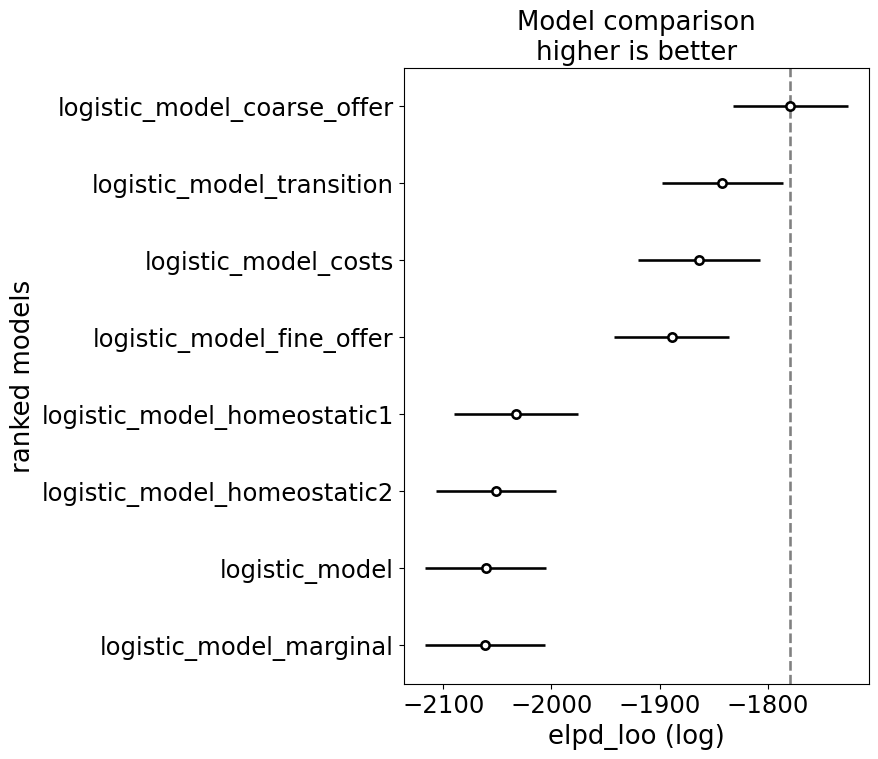

In [22]:
# Compare the models:
model_comparison = az.compare(traces)
az.plot_compare(model_comparison);
model_comparison

# Planning model
As we can see, both the models with offer and costs are fitting the data much better than any other prior. We will therefore take them to the next round. We will fit the planning model from Ott, the logistic models with offers and costs specific action priors, as well as models where we add the offers and costs action priors to the planning model. The reason is that we want to know whether the simple logistic regression might outperform the planning model across the board. It could be the case as these models have lower complexity, yet they seem to be able to explain a good amount of variance. 

Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, is_basic, is_full_energy, is_low_energy_LC, is_low_energy_HC, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset, is_basic|vpn_sigma, is_basic|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 111 seconds.
Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, logitP_A_offer_coarse, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset, logitP_A_offer_coarse|vpn_sigma, logitP_A_offer_coarse|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 40 seconds.
Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, logitP_A_costs, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset, logitP_A_costs|vpn_sigma, logitP_A_costs|vpn_offset]


...

Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 79 seconds.
Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, is_basic, is_full_energy, is_low_energy_LC, is_low_energy_HC, logitP_A_transition, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset, is_basic|vpn_sigma, is_basic|vpn_offset, logitP_A_transition|vpn_sigma, logitP_A_transition|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 78 seconds.
/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
planning_model_offer,0,-1704.634385,126.220352,0.000000,6.930658e-01,53.367753,0.000000,True,log
logistic_model_offer,1,-1779.089896,103.490507,74.455511,1.072416e-12,52.877005,13.833373,False,log
planning_model_transition,2,-1813.671716,127.590002,109.037331,3.069342e-01,55.737589,26.498933,True,log
planning_model_costs,3,-1836.300251,127.874389,131.665866,0.000000e+00,56.656809,24.804580,True,log
logistic_model_costs,4,-1863.130539,104.138992,158.496154,0.000000e+00,56.506156,25.311604,False,log
planning_model,5,-2032.562595,90.659324,327.928210,1.063632e-10,55.123435,25.448608,True,log


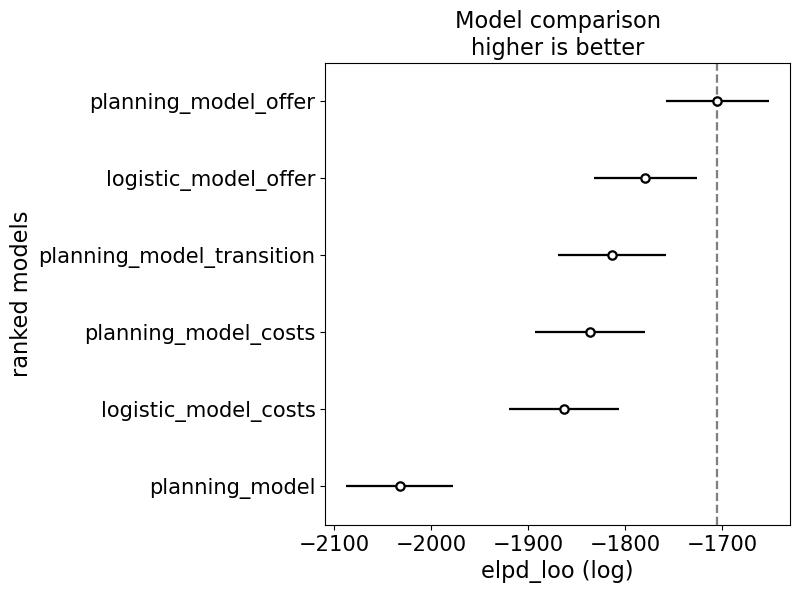

In [23]:
traces = {}

# ===================================================================
# Ott's planning model (Benchmark):
planning_model = bmb.Model(
    "response ~ dv + is_basic + is_full_energy + is_low_energy_LC + is_low_energy_HC + "
    "(dv + is_basic|vpn)", 
    data, 
    family="bernoulli")
traces['planning_model'] = planning_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# ===================================================================
# Logistic hierarchical model with coarse offers action prior:
logistic_model_offer = bmb.Model(
    "response ~ dv + logitP_A_offer_coarse + (dv + logitP_A_offer_coarse|vpn)", 
    data, 
    family="bernoulli")
traces['logistic_model_offer'] = logistic_model_offer.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# ===================================================================
# Logistic hierarchical model with costs based action priors
logistic_model_costs = bmb.Model(
    "response ~ dv + logitP_A_costs + (dv + logitP_A_costs|vpn)", 
    data, 
    family="bernoulli")
traces['logistic_model_costs'] = logistic_model_costs.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# ===================================================================
# Planning model combined with offer specific action prior:
planning_model_offer = bmb.Model(
    "response ~ dv + is_basic + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_offer_coarse + "
    "(dv + is_basic + logitP_A_offer_coarse|vpn)", 
    data, 
    family="bernoulli")
traces['planning_model_offer'] = planning_model_offer.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# ===================================================================
# Planning model combined with costs specific action prior:
planning_model_costs = bmb.Model(
    "response ~ dv + is_basic + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_costs + "
    "(dv + is_basic + logitP_A_costs|vpn)", 
    data, 
    family="bernoulli")
traces['planning_model_costs'] = planning_model_costs.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# ===================================================================
# Planning model combined with transitions specific action prior:
planning_model_transition = bmb.Model(
    "response ~ dv + is_basic + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_transition + "
    "(dv + is_basic + logitP_A_transition|vpn)", 
    data, 
    family="bernoulli")
traces['planning_model_transition'] = planning_model_transition.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# Compare the models:
model_comparison = az.compare(traces)
az.plot_compare(model_comparison);
model_comparison

# Hybrid model
The best performing model is the planning one augmented with the offer prior. This indicate that the additional regressors of the planning model explain something above and beyond the offer priors. Importantly, that extra something isn't all that much, because the simpler logistic regression is really close. These additional regressors relate to the energy level. We did test a model with energy dependent action priors, which did not seem to add much compared to models without it. Importantly, we have tested two version of what we call the homeostatic prior, but it could very well be that the priors are wrong, and that better suited priors could exist. 

Finally, while we can see that the action prior constitute a really good addition to the planning model from Ott (both the offers and the costs prior), the real question is how they fair against the hybrid model from Ott. Ott's hybrid was found to fit the data the best in the original study, which was taken as evidence that participants behaviour is the result of some mixture of forward planning and heuristics known from previous experience in a context dependent fashion. The hybrid model contained planning related regressors, as well as constants associated with separate "contexts" representing heuristic weights participants attribute to different situation. While the idea is similar to policy compression, it differs in the sense that with policy compression, the reliance on prior vs. forward planning is a function of the entropy of the prior and decision values. That is, if the Q values associated with a particular state is close to 0.5 but the prior is closer to 1 or 0, the prior will dominate and vice versa. 

It could therefore be the case that the use of action priors supplants the need for state specific constants used in Ott's model, which would suggest that the use of action priors constitutes a more parsimonious model that the hybrid model from Ott (i.e. we capture the same behaviour in a simpler way). To test that idea, we will fit the models from the previous round and compare them to the hybrid model. We will further enrich Ott's model with the action priors to test whether the two capture relevance yet different aspects of the data. 

Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv_23, dv_14, is_1, is_2, is_3, is_4, is_full_energy, is_low_energy_LC, is_low_energy_HC, 1|vpn_sigma, 1|vpn_offset, dv_23|vpn_sigma, dv_23|vpn_offset, dv_14|vpn_sigma, dv_14|vpn_offset, is_1|vpn_sigma, is_1|vpn_offset, is_2|vpn_sigma, is_2|vpn_offset, is_3|vpn_sigma, is_3|vpn_offset, is_4|vpn_sigma, is_4|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 112 seconds.
Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, is_basic, is_full_energy, is_low_energy_LC, is_low_energy_HC, logitP_A_offer_coarse, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset, is_basic|vpn_sigma, is_basic|vpn_offset, logitP_A_offer_coarse|vpn_sigma, logitP_A_offer_coarse|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 81 seconds.
Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv, is_basic, is_full_energy, is_low_energy_LC, is_low_energy_HC, logitP_A_costs, 1|vpn_sigma, 1|vpn_offset, dv|vpn_sigma, dv|vpn_offset, is_basic|vpn_sigma, is_basic|vpn_offset, logitP_A_costs|vpn_sigma, logitP_A_costs|vpn_offset]


...

Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 132 seconds.
Modeling the probability that response==1
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, dv_23, dv_14, is_1, is_2, is_3, is_4, is_full_energy, is_low_energy_LC, is_low_energy_HC, logitP_A_transition, 1|vpn_sigma, 1|vpn_offset, dv_23|vpn_sigma, dv_23|vpn_offset, dv_14|vpn_sigma, dv_14|vpn_offset, is_1|vpn_sigma, is_1|vpn_offset, is_2|vpn_sigma, is_2|vpn_offset, is_3|vpn_sigma, is_3|vpn_offset, is_4|vpn_sigma, is_4|vpn_offset, logitP_A_transition|vpn_sigma, logitP_A_transition|vpn_offset]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 178 seconds.
/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/alex-lepauvre/miniforge3/envs/pymc_env/lib/python3.14/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely t

,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
hybrid_model_transition,0,-1591.417472,192.412206,0.000000,5.804435e-01,51.304784,0.000000,True,log
hybrid_model_costs,1,-1605.181395,188.282821,13.763923,3.347147e-01,50.790489,12.147498,True,log
hybrid_model_offer,2,-1674.487646,160.979803,83.070174,1.401367e-11,52.092860,14.659634,True,log
hybrid_model,3,-1675.603938,158.881793,84.186466,1.488880e-11,52.088855,14.643531,True,log
planning_model_offer,4,-1705.039406,126.610909,113.621934,3.935955e-02,53.450601,19.108366,True,log
planning_model_costs,5,-1836.164557,127.229189,244.747085,4.548224e-02,56.551450,27.120864,True,log


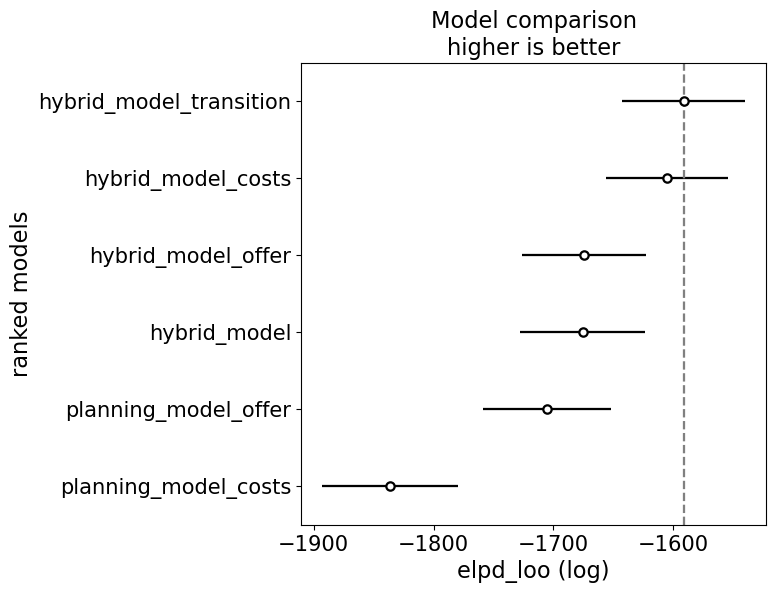

In [24]:
traces = {}

# ===================================================================
# Hybrid model from Ott's (Benchmark)
hybrid_model = bmb.Model(
    "response ~ dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + is_full_energy + is_low_energy_LC + is_low_energy_HC + "
    "(dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4|vpn)", 
    data, 
    family="bernoulli")
traces['hybrid_model'] = hybrid_model.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# ===================================================================
# Planning model combined with offer specific action prior:
planning_model_offer = bmb.Model(
    "response ~ dv + is_basic + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_offer_coarse + "
    "(dv + is_basic + logitP_A_offer_coarse|vpn)", 
    data, 
    family="bernoulli")
traces['planning_model_offer'] = planning_model_offer.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# ===================================================================
# Planning model combined with offer specific action prior:
planning_model_costs = bmb.Model(
    "response ~ dv + is_basic + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_costs + "
    "(dv + is_basic + logitP_A_costs|vpn)", 
    data, 
    family="bernoulli")
traces['planning_model_costs'] = planning_model_costs.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# ===================================================================
# Hybrid model with offer specific action prior:
hybrid_model_offer = bmb.Model(
    "response ~ dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_offer_coarse +"
    "(dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + logitP_A_offer_coarse|vpn)", 
    data, 
    family="bernoulli")
traces['hybrid_model_offer'] = hybrid_model_offer.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# ===================================================================
# Hybrid model with costs specific action prior:
hybrid_model_costs = bmb.Model(
    "response ~ dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_costs +"
    "(dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + logitP_A_costs|vpn)", 
    data, 
    family="bernoulli")
traces['hybrid_model_costs'] = hybrid_model_costs.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# ===================================================================
# Hybrid model with transition specific action prior:
hybrid_model_transition = bmb.Model(
    "response ~ dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + is_full_energy + is_low_energy_LC + is_low_energy_HC + logitP_A_transition +"
    "(dv_23 + dv_14 + is_1 + is_2 + is_3 + is_4 + logitP_A_transition|vpn)", 
    data, 
    family="bernoulli")
traces['hybrid_model_transition'] = hybrid_model_transition.fit(
    draws=1000, target_accept=0.85, idata_kwargs={"log_likelihood": True}
)

# Compare the models:
model_comparison = az.compare(traces)
az.plot_compare(model_comparison);
model_comparison

# Discussion
Our results indicate that action prior are quite powerful at explaning participants' behaviour, suggesting that participants might indeed be doing an initial abstraction of the task by determining priors for certain chunks of the state space. However, the priors alone are not sufficient, as the best fitting models are not simple logistic regression with the added action priors, but rather requires the additional pararmeters from Ott's original paper. 

Interestingly, the offer prior when combined with Ott's hybrid model shows performances that are on par with the hybrid model without it. This might indicate that the additional offer specific regressors from Ott's model are accounting for similar aspects of the data as the offer prior. However, if that were the case, then we would expect the planning model combined with offer specific action priors to perform equally well as the hybrid model or even better the planning model with offer specific prior is less complex than the hybrid model. The fact that this is not the case suggests that the offer prior does not cover everything the hybrid priors extra parameters covers. 

Another interesting point is that the hybrid model combined with the costs action prior shows the best fit, despite the planning model with costs action prior not performing very well. A potential explanation for this is that the variance covered by the costs action prior does not overlap with the variance covered by the offer dependent action prior nor with the additional regressors from the hybrid model. 

To sum up, the fact that the hybrid model combined with costs specific prior performs the best suggests that participants might rely on state dependent action priors. Importantly, we have so far only considered models with priors that depend only on a single factor from the MDP (either energy, offer or costs). We can however combine different state dependent priors to model participants data to test whether participants might indeed be combining priors from different aspects of the MDP to decide on which action to perform. Specifically, based on what we have seen so far, it would be expected that combining the offer and costs dependent priors might yield yet even better results, without having to rely on the additional priors from the hybrid model. This is what we will test in the next notebook.